In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Load Madelon dataset
X, y = fetch_openml(
    name="madelon",
    version=1,
    return_X_y=True,
    as_frame=False,
    data_home="openml_cache"
)

# Convert labels
y = y.astype(int)

print("Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)


Dataset Shape: (2600, 500)
Labels Shape: (2600,)


In [3]:
# Use subset for faster execution
X = X[:2000]
y = y[:2000]

print("Subset Shape:", X.shape)

Subset Shape: (2000, 500)


## Dataset Graphs

These graphs show class balance and a quick two-feature view of the subset.


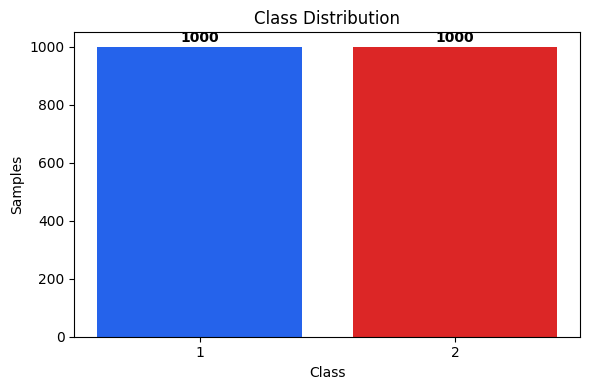

In [4]:
# Added visualization: project2 dataset overview
import numpy as np
import matplotlib.pyplot as plt

labels, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(6, 4))

plt.bar([str(label) for label in labels], counts, color=["#2563eb", "#dc2626"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Samples")

# Add count labels on top
for i, count in enumerate(counts):
    plt.text(i, count + 15, str(count), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1400, 500)
(600, 500)


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaling completed.")

Data scaling completed.


In [7]:
# Baseline model using SVM

baseline_model = model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale'
)

baseline_model.fit(X_train_scaled, y_train)

baseline_accuracy = baseline_model.score(
    X_test_scaled,
    y_test
)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.5383333333333333


In [8]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

# Select top important features

selector = SelectKBest(
    score_func=f_classif,
    k=50
)

X_train_selected = selector.fit_transform(
    X_train_scaled,
    y_train
)

X_test_selected = selector.transform(
    X_test_scaled
)

selected_features = selector.get_support(indices=True)

print("Selected Features:", len(selected_features))

Selected Features: 50


## Fitness Function

This function evaluates each wolf by training an SVM on the selected feature subset.


In [9]:
# Added function: project2 GWO fitness

def fitness(solution):
    selected = np.where(solution == 1)[0]

    if len(selected) == 0:
        return 1.0

    clf = SVC(kernel="rbf", C=10, gamma="scale")
    accuracy = cross_val_score(
        clf,
        X_train_scaled[:, selected],
        y_train,
        cv=3
    ).mean()

    feature_penalty = 0.02 * (len(selected) / X.shape[1])
    return (1 - accuracy) + feature_penalty


In [10]:
# GWO parameters

n_wolves = 12
iterations = 30
dim = X.shape[1]

# Sparse initialization
wolves = np.random.choice(
    [0, 1],
    size=(n_wolves, dim),
    p=[0.9, 0.1]
)

print("Wolves Shape:", wolves.shape)

Wolves Shape: (12, 500)


In [11]:
best_fitness_history = []

for iteration in range(iterations):

    # Calculate fitness for each wolf
    fitness_values = np.array([
        fitness(wolf)
        for wolf in wolves
    ])

    # Sort wolves
    sorted_idx = np.argsort(fitness_values)

    alpha = wolves[sorted_idx[0]].copy()
    beta = wolves[sorted_idx[1]].copy()
    delta = wolves[sorted_idx[2]].copy()

    best_fitness = fitness_values[sorted_idx[0]]

    best_fitness_history.append(best_fitness)

    # Update wolves
    for i in range(n_wolves):

        rand = np.random.rand(dim)

        wolves[i] = np.where(
            rand < 0.5,
            alpha,
            np.where(rand < 0.75, beta, delta)
        )

        # Limit selected features
        if np.sum(wolves[i]) > 50:

            ones_idx = np.where(wolves[i] == 1)[0]

            remove_idx = np.random.choice(
                ones_idx,
                size=(len(ones_idx) - 50),
                replace=False
            )

            wolves[i][remove_idx] = 0

    print(
        f"Iteration {iteration+1}/{iterations} | "
        f"Best Fitness: {best_fitness:.4f}"
    )

Iteration 1/30 | Best Fitness: 0.4090
Iteration 2/30 | Best Fitness: 0.3713
Iteration 3/30 | Best Fitness: 0.3856
Iteration 4/30 | Best Fitness: 0.3713
Iteration 5/30 | Best Fitness: 0.3691
Iteration 6/30 | Best Fitness: 0.3612
Iteration 7/30 | Best Fitness: 0.3497
Iteration 8/30 | Best Fitness: 0.3497
Iteration 9/30 | Best Fitness: 0.3497
Iteration 10/30 | Best Fitness: 0.3497
Iteration 11/30 | Best Fitness: 0.3497
Iteration 12/30 | Best Fitness: 0.3497
Iteration 13/30 | Best Fitness: 0.3497
Iteration 14/30 | Best Fitness: 0.3497
Iteration 15/30 | Best Fitness: 0.3497
Iteration 16/30 | Best Fitness: 0.3497
Iteration 17/30 | Best Fitness: 0.3497
Iteration 18/30 | Best Fitness: 0.3497
Iteration 19/30 | Best Fitness: 0.3497
Iteration 20/30 | Best Fitness: 0.3497
Iteration 21/30 | Best Fitness: 0.3497
Iteration 22/30 | Best Fitness: 0.3497
Iteration 23/30 | Best Fitness: 0.3497
Iteration 24/30 | Best Fitness: 0.3497
Iteration 25/30 | Best Fitness: 0.3497
Iteration 26/30 | Best Fitness: 0.

## GWO Convergence Graph

This plot shows how the best fitness changes over iterations.


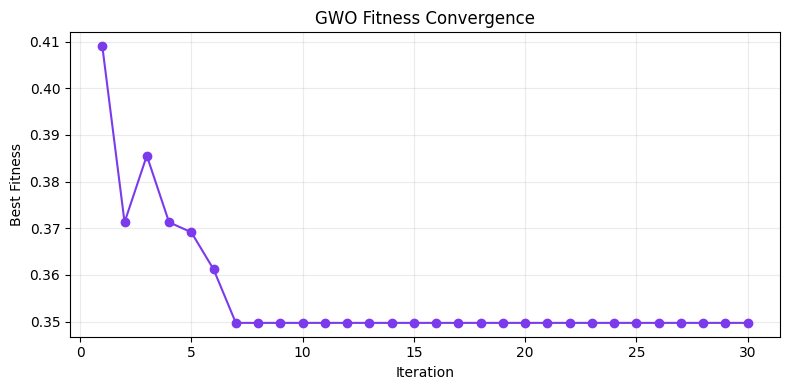

In [12]:
# Added visualization: project2 convergence
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(best_fitness_history) + 1), best_fitness_history, marker="o", color="#7c3aed")
plt.title("GWO Fitness Convergence")
plt.xlabel("Iteration")
plt.ylabel("Best Fitness")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [13]:
# Best solution

best_solution = alpha

selected_features = np.where(
    best_solution == 1
)[0]

print("Number of Selected Features:",
      len(selected_features))

print("Selected Feature Indices:")
print(selected_features)

Number of Selected Features: 47
Selected Feature Indices:
[ 11  17  19  30  33  42  48  55  63  68  80  82  88 104 122 126 128 130
 136 138 140 145 153 168 169 187 197 215 230 241 250 257 281 309 327 350
 353 354 360 373 379 394 426 432 442 469 475]


## Selected Feature Graphs

These graphs show which feature positions were selected by GWO.


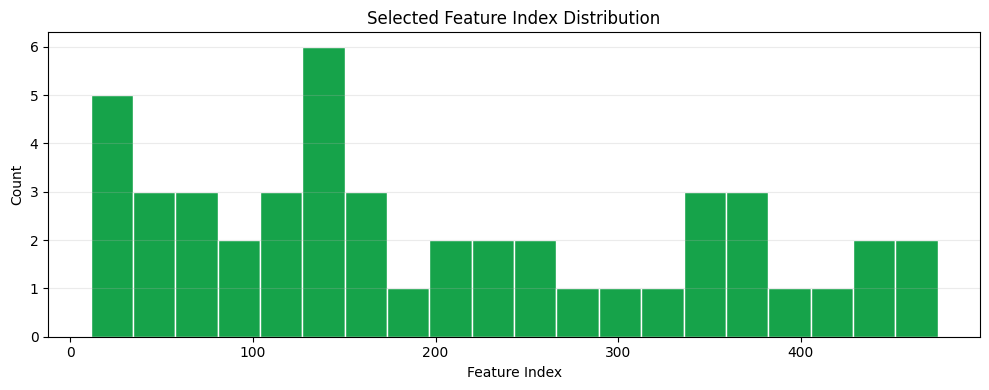

In [18]:
# Added visualization: project2 selected features
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.hist(selected_features, bins=20, color="#16a34a", edgecolor="white")

plt.title("Selected Feature Index Distribution")
plt.xlabel("Feature Index")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [15]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

# Select top 150 features
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=150
)

X_train_selected = selector.fit_transform(
    X_train_scaled,
    y_train
)

X_test_selected = selector.transform(
    X_test_scaled
)

# Random Forest Model
final_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    max_features='sqrt',
    random_state=42
)

final_model.fit(
    X_train_selected,
    y_train
)

final_accuracy = final_model.score(
    X_test_selected,
    y_test
)

print("Final Accuracy:", final_accuracy)

Final Accuracy: 0.745


## Final Result Graphs

These plots summarize accuracy and feature reduction.


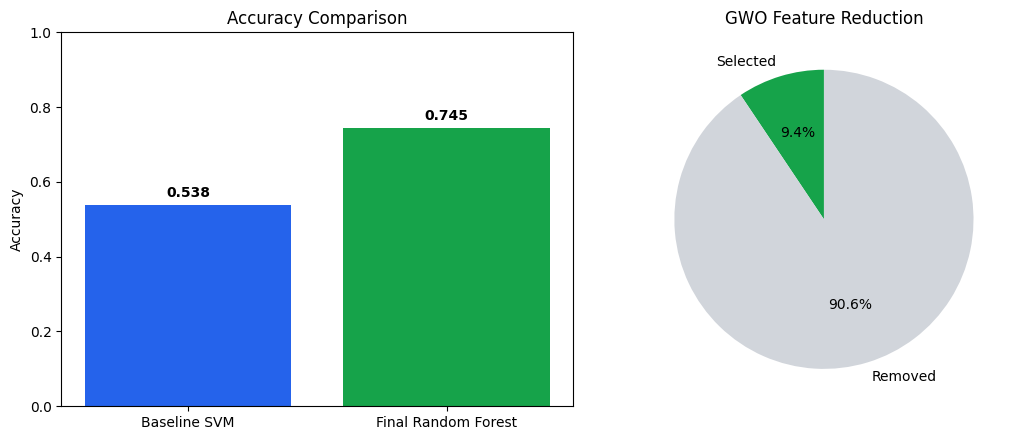

In [ ]:
# Added visualization: project2 final dashboard
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

accuracy_names = ["Baseline SVM", "Final Random Forest"]
accuracy_values = [baseline_accuracy, final_accuracy]
bars = axes[0].bar(accuracy_names, accuracy_values, color=["#2563eb", "#16a34a"])
axes[0].set_title("Accuracy Comparison")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
for bar, value in zip(bars, accuracy_values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        fontweight="bold"
    )

axes[1].pie(
    [len(selected_features), X.shape[1] - len(selected_features)],
    labels=["Selected", "Removed"],
    autopct="%1.1f%%",
    colors=["#16a34a", "#d1d5db"],
    startangle=90
)
axes[1].set_title("GWO Feature Reduction")

plt.tight_layout()
plt.show()

